# IRIS DATASET - PRINCIPAL COMPONENT ANALYSIS

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.stats import f_oneway

In [2]:
iris_df = sns.load_dataset('iris')

## What is this notebook about
The Iris dataset has 150 flowers from three species - Setosa, Versicolor and Virginica. Each flower has four measurements: sepal length, sepal width, petal length and petal width, all in centimetres.
The question I want to answer is whether all four measurements are actually necessary or whether most of the information is concentrated in fewer directions. This is what PCA does. It finds the directions in the data that carry the most variation and lets you project everything onto those. If two directions are enough to capture most of the variance you can go from a 4-dimensional dataset to a 2D plot without losing much.
I studied PCA in my MML course and wanted to actually run it on real data to see if the theory holds up.

## How PCA actually works
PCA finds the directions of maximum variance in the data. These directions are called principal components. The first component points in the direction of highest variance, the second points in the direction of highest remaining variance that is also perpendicular to the first, and so on.
The proportion of variance each component explains is its eigenvalue divided by the sum of all eigenvalues. So if PC1 accounts for 73% of the total that means 73% of what varies across the dataset is captured in that one direction.
One thing you have to do before running PCA is standardise the data - subtract the mean and divide by the standard deviation for each feature. The reason is that PCA picks up on variance so a feature measured in large numbers will dominate just because of its scale, not because it actually carries more information. Standardising puts everything on the same scale first.

## Prima Facie Analysis of Data

In [3]:
iris_df.head(10)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


In [4]:
print(iris_df.shape)
print(iris_df['species'].value_counts())
print(iris_df.isnull().sum())

(150, 5)
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


150 flowers, 50 per species, no missing values. Clean dataset.

In [5]:
iris_df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


The petal measurements have higher standard deviations relative to their means compared to the sepal measurements. That suggests petal size varies more across species which is a hint that petal features might be more useful for telling the species apart.

## Distribution of Features

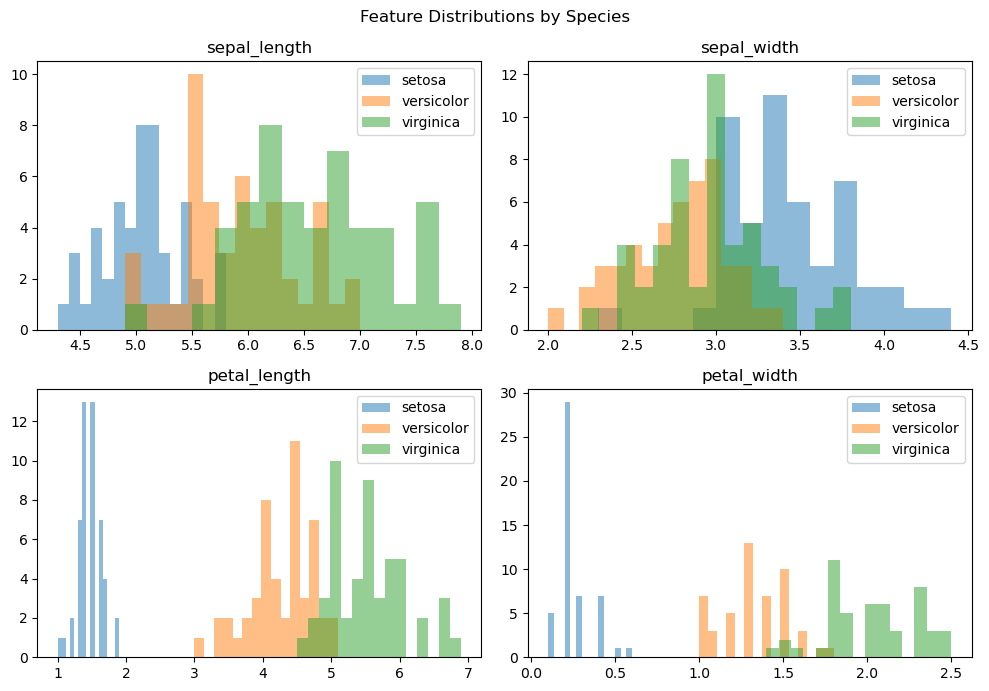

In [6]:
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
axes = axes.flatten()

for i, col in enumerate(features):
    for species in iris_df['species'].unique():
        data = iris_df[iris_df['species'] == species][col]
        axes[i].hist(data, alpha=0.5, label=species, bins=15)
    axes[i].set_title(col)
    axes[i].legend()

plt.suptitle('Feature Distributions by Species')
plt.tight_layout()
plt.show()

Setosa is clearly separated from the other two on petal length and petal width. Versicolor and Virginica overlap more. Sepal width is the most mixed - all three species sit fairly close together on it which means it probably does not add much on its own.

## Correlation Between Features
Before running PCA it helps to look at how correlated the features are with each other. If two features are very highly correlated they are basically measuring the same thing twice, which means we do not actually have four independent dimensions of information. PCA should be able to compress those into one direction.

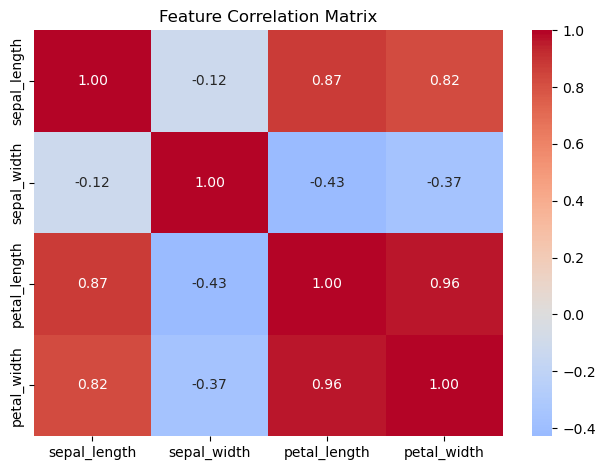

In [7]:
corr_matrix = iris_df[features].corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

Petal length and petal width have a correlation of 0.96 which is very high. They are essentially measuring the same thing. Sepal length also correlates strongly with both petal features at around 0.87. Sepal width barely correlates with anything.
This already tells us the four features are not four independent pieces of information. PCA should pick this up and compress most of the variance into fewer components.

## Standardising the Data

In [8]:
X = iris_df[features].values
y = iris_df['species'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# checking it worked
print('means after scaling:', X_scaled.mean(axis=0).round(4))
print('stds after scaling:', X_scaled.std(axis=0).round(4))

means after scaling: [-0. -0. -0. -0.]
stds after scaling: [1. 1. 1. 1.]


All features now have mean 0 and standard deviation 1 so PCA will treat them equally.

## Applying PCA

In [9]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

evr = pca.explained_variance_ratio_
cumulative = np.cumsum(evr)

for i in range(4):
    print(f'PC{i+1}: {evr[i]*100:.2f}%  cumulative: {cumulative[i]*100:.2f}%')

PC1: 72.96%  cumulative: 72.96%
PC2: 22.85%  cumulative: 95.81%
PC3: 3.67%  cumulative: 99.48%
PC4: 0.52%  cumulative: 100.00%


PC1 alone captures about 73% of the variance. PC1 and PC2 together get to 96%. So two components are basically enough. PC3 and PC4 together only add about 4% which is not worth keeping.

## Explained Variance Plot

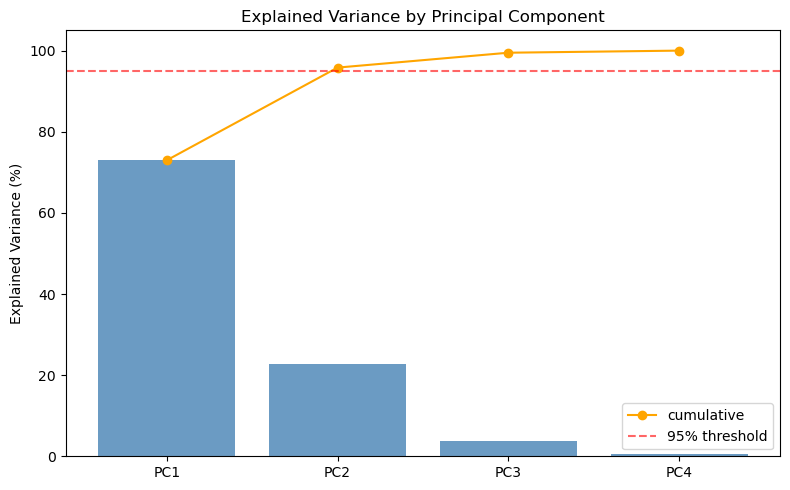

In [10]:
components = ['PC1', 'PC2', 'PC3', 'PC4']

plt.figure(figsize=(8, 5))
plt.bar(components, evr * 100, color='steelblue', alpha=0.8)
plt.plot(components, cumulative * 100, color='orange', marker='o', label='cumulative')
plt.axhline(y=95, color='red', linestyle='--', alpha=0.6, label='95% threshold')
plt.ylabel('Explained Variance (%)')
plt.title('Explained Variance by Principal Component')
plt.legend()
plt.tight_layout()
plt.show()

The cumulative line crosses 95% after just two components. This is the point where adding more components stops being worth it.

## What do PC1 and PC2 actually represent
Each principal component is a weighted combination of the original features. The weights are called loadings. A large loading means that feature contributes a lot to that component.

In [11]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=features,
    columns=['PC1', 'PC2', 'PC3', 'PC4']
).round(3)

print(loadings)

                PC1    PC2    PC3    PC4
sepal_length  0.521  0.377  0.720 -0.261
sepal_width  -0.269  0.923 -0.244  0.124
petal_length  0.580  0.024 -0.142  0.801
petal_width   0.565  0.067 -0.634 -0.524


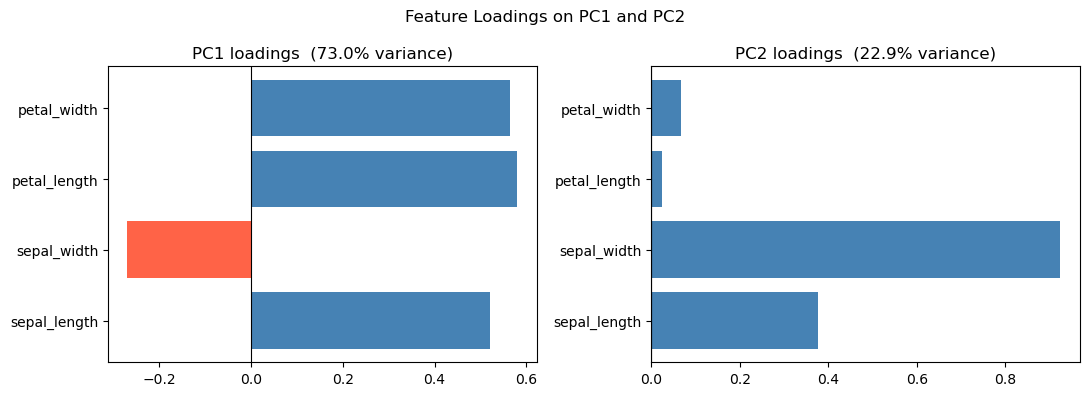

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for idx, pc in enumerate(['PC1', 'PC2']):
    vals = loadings[pc]
    colors = ['steelblue' if v >= 0 else 'tomato' for v in vals]
    axes[idx].barh(features, vals, color=colors)
    axes[idx].axvline(0, color='black', linewidth=0.8)
    axes[idx].set_title(f'{pc} loadings  ({evr[idx]*100:.1f}% variance)')

plt.suptitle('Feature Loadings on PC1 and PC2')
plt.tight_layout()
plt.show()

PC1 has large negative loadings on petal length, petal width and sepal length. Flowers with bigger petals and longer sepals score lower on PC1. Setosa, which has the smallest petals, will sit on the positive end. PC1 is basically a size axis.
PC2 is mostly sepal width pulling positive and sepal length pulling negative. It is capturing something about the shape of the sepal independent of overall size.
The petal length and petal width loadings on PC1 are almost identical which makes sense given how correlated they were. They are pointing in the same direction because they carry the same information.

## Projecting onto 2D

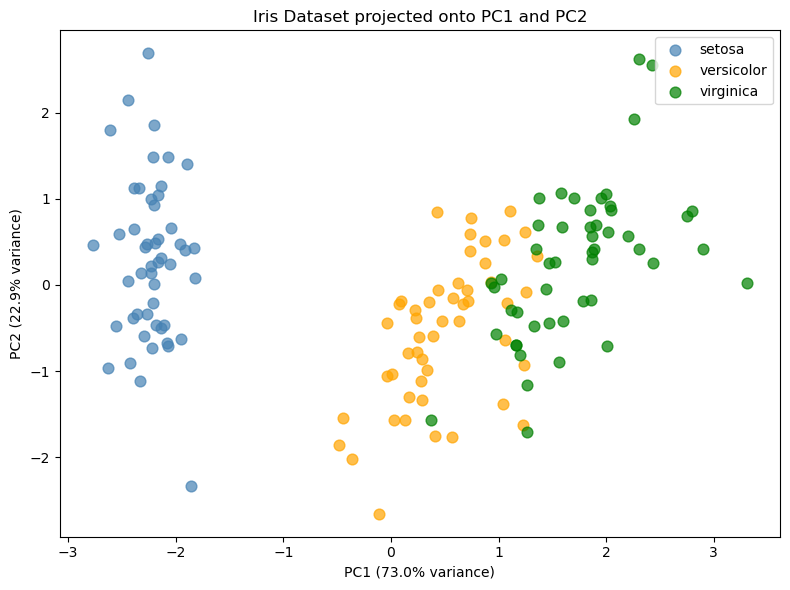

In [13]:
pca_df = pd.DataFrame({'PC1': X_pca[:, 0], 'PC2': X_pca[:, 1], 'species': y})

colors = {'setosa': 'steelblue', 'versicolor': 'orange', 'virginica': 'green'}

plt.figure(figsize=(8, 6))
for species in pca_df['species'].unique():
    subset = pca_df[pca_df['species'] == species]
    plt.scatter(subset['PC1'], subset['PC2'], label=species,
                c=colors[species], alpha=0.7, s=60)

plt.xlabel(f'PC1 ({evr[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({evr[1]*100:.1f}% variance)')
plt.title('Iris Dataset projected onto PC1 and PC2')
plt.legend()
plt.tight_layout()
plt.show()

Setosa is completely separated from the other two. Versicolor and Virginica overlap a bit but they were never cleanly separable even in the original four dimensions. The structure has survived the dimensionality reduction.

## Checking the separation statistically
The scatter plot looks like the three species are separated along PC1 but I want to check if this is actually statistically significant or just looks that way visually. A one way ANOVA tests whether the mean PC1 score is the same across all three species.
H0 : mean PC1 score is equal across all three species
H1 : at least one species has a different mean PC1 score

In [14]:
setosa_pc1 = pca_df[pca_df['species'] == 'setosa']['PC1']
versicolor_pc1 = pca_df[pca_df['species'] == 'versicolor']['PC1']
virginica_pc1 = pca_df[pca_df['species'] == 'virginica']['PC1']

f_stat, p_val = f_oneway(setosa_pc1, versicolor_pc1, virginica_pc1)

print(f'F-statistic: {f_stat:.2f}')
print(f'p-value: {p_val:.4e}')
print()
print('mean PC1 by species:')
print(pca_df.groupby('species')['PC1'].mean().round(3))

F-statistic: 1050.63
p-value: 8.6510e-88

mean PC1 by species:
species
setosa       -2.225
versicolor    0.496
virginica     1.728
Name: PC1, dtype: float64


p-value is essentially zero so we reject H0. The separation we saw in the plot is real and not just noise.

# Summary
##### The Iris dataset has four features but they are not carrying four independent pieces of information. Petal length and petal width are correlated at 0.96 which means they are essentially measuring the same thing. Because of this, PCA is able to compress most of the variance into just two components - PC1 captures 73% on its own and together with PC2 gets to 96%. The 2D projection still separates the three species almost as cleanly as the original four dimensions did and the ANOVA confirms the separation on PC1 is statistically significant. The dataset looks four dimensional but it is effectively two dimensional.

### - Dushyant Singh Taggar